In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [7]:
kr_clean_files = [
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]

kr_clean_files


['Ethiopia_KR_2008_clean.csv',
 'Ethiopia_KR_2011_clean.csv',
 'Kenya_KR_2014_clean.csv',
 'Kenya_KR_2022_clean.csv',
 'Tanzania_KR_2010_clean.csv',
 'Tanzania_KR_2015_clean.csv',
 'Tanzania_KR_2022_clean.csv',
 'Uganda_KR_2011_clean.csv',
 'Uganda_KR_2016_clean.csv']

In [15]:
stunting_rows = []

for fname in kr_clean_files:
    print("working on", fname)
    
    df = pd.read_csv(fname)
    
    # get country from file name
    country = fname.split("_")[0]
    
    # survey year from your cleaned column
    year = df["interview year"].iloc[0]
    
    # drop rows where HAZ is missing
    if "height for age SD per WHO" not in df.columns:
        print("  no HAZ column here, skipping")
        continue
    
    haz = df["height for age SD per WHO"].dropna()
    
    if len(haz) == 0:
        print("  no non-missing HAZ in this file, skipping")
        continue
    
    # stunted = HAZ < -2
    is_stunted = haz < -2
    stunting_rate = is_stunted.mean()
    
    stunting_rows.append({
        "country": country,
        "survey_year": year,
        "stunting_rate": stunting_rate
    })

stunting_summary = pd.DataFrame(stunting_rows)
stunting_summary.sort_values(["country", "survey_year"])


working on Ethiopia_KR_2008_clean.csv
working on Ethiopia_KR_2011_clean.csv
working on Kenya_KR_2014_clean.csv
working on Kenya_KR_2022_clean.csv
working on Tanzania_KR_2010_clean.csv
working on Tanzania_KR_2015_clean.csv
working on Tanzania_KR_2022_clean.csv
working on Uganda_KR_2011_clean.csv
working on Uganda_KR_2016_clean.csv


,country,survey_year,stunting_rate
0,Ethiopia,2008,0.786900
1,Ethiopia,2011,0.829107
2,Kenya,2014,0.802739
3,Kenya,2022,0.770188
4,Tanzania,2010,0.832474
5,Tanzania,2015,0.861467
6,Tanzania,2022,0.867465
7,Uganda,2011,0.784553
8,Uganda,2016,0.810337


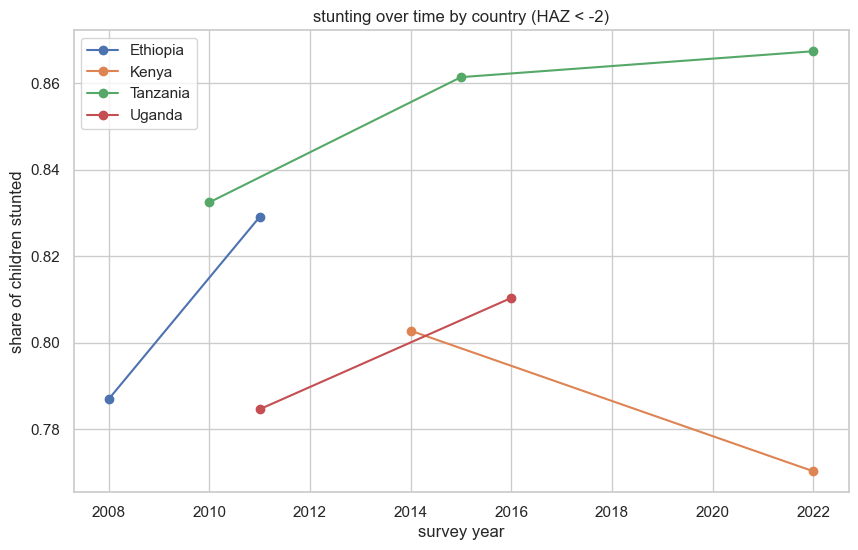

In [17]:
plt.figure(figsize=(10, 6))

for country, group in stunting_summary.groupby("country"):
    g = group.sort_values("survey_year")
    plt.plot(g["survey_year"], g["stunting_rate"], marker="o", label=country)

plt.xlabel("survey year")
plt.ylabel("share of children stunted")
plt.title("stunting over time by country (HAZ < -2)")
plt.legend()
plt.show()


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

kenya_files = [
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
]

kenya_rows = []

for fname in kenya_files:
    print("reading", fname)
    df = pd.read_csv(fname)
    
    # survey year
    year = df["interview year"].iloc[0]
    
    # make sure we have the HAZ column
    if "height for age SD per WHO" in df.columns:
        haz_col = "height for age SD per WHO"
    else:
        print("  no HAZ column here, skipping", fname)
        continue
    
    # try a couple of possible wealth names
    wealth_col = None
    if "wealth_quartile" in df.columns:
        wealth_col = "wealth_quartile"
    elif "wealth_quintile" in df.columns:
        wealth_col = "wealth_quintile"
    elif "wealth index combined" in df.columns:
        wealth_col = "wealth index combined"
    
    if wealth_col is None:
        print("  could not find a wealth column, skipping", fname)
        # print([c for c in df.columns if "wealth" in c.lower()])  # uncomment if you want to debug
        continue
    
    print("  using wealth column:", wealth_col)
    
    # drop missing HAZ and wealth
    sub = df[[haz_col, wealth_col]].dropna()
    
    # flag stunted
    sub["is_stunted"] = sub[haz_col] < -2
    
    # stunting rate by wealth group
    by_wealth = (
        sub.groupby(wealth_col)["is_stunted"]
        .mean()
        .reset_index()
    )
    by_wealth["survey_year"] = year
    by_wealth = by_wealth.rename(columns={wealth_col: "wealth_group"})
    
    kenya_rows.append(by_wealth)

kenya_stunting_wealth = pd.concat(kenya_rows, ignore_index=True)
kenya_stunting_wealth



reading Kenya_KR_2014_clean.csv
  using wealth column: wealth index combined
reading Kenya_KR_2022_clean.csv
  using wealth column: wealth_quartile


,wealth_group,is_stunted,survey_year
0,1,0.829670,2014
1,2,0.844389,2014
2,3,0.817951,2014
3,4,0.779545,2014
4,5,0.667903,2014
5,1,0.804485,2022
6,2,0.788214,2022
7,3,0.764435,2022
8,4,0.735374,2022
9,5,0.689813,2022


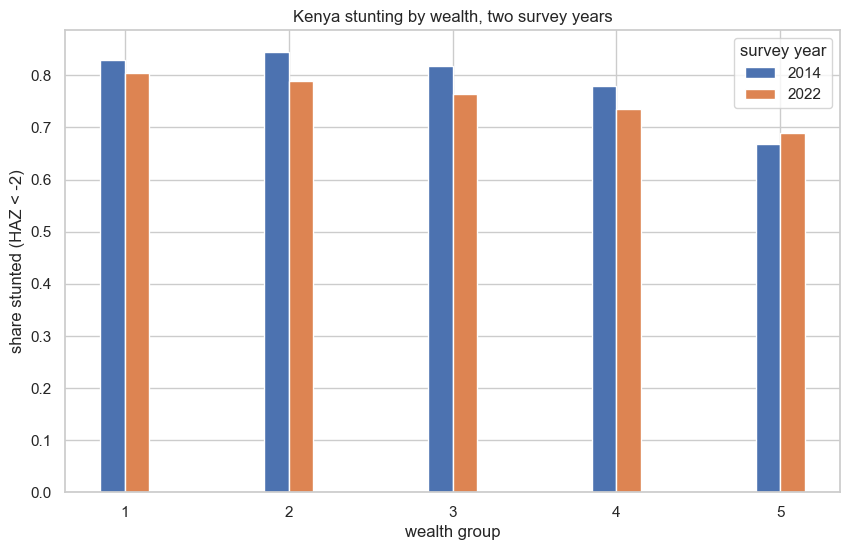

In [25]:
plt.figure(figsize=(10, 6))

years = sorted(kenya_stunting_wealth["survey_year"].unique())

for i, year in enumerate(years):
    data = kenya_stunting_wealth[kenya_stunting_wealth["survey_year"] == year]
    x = data["wealth_group"]
    y = data["is_stunted"]
    
    # convert to positions for plotting
    x_pos = range(len(x))
    offset = (i - 0.5) * 0.15  # just nudging bars
    
    plt.bar(
        [p + offset for p in x_pos],
        y,
        width=0.15,
        label=str(year)
    )

plt.xticks(range(len(x)), x)
plt.xlabel("wealth group")
plt.ylabel("share stunted (HAZ < -2)")
plt.title("Kenya stunting by wealth, two survey years")
plt.legend(title="survey year")
plt.show()

